# 02 · Broad basketball feature research

**3,106 candidates; training-only screening; matched temporal ablations.** This is a deliberately broad hypothesis search, not a claim that every generated column is useful. Every displayed result is loaded from a completed, checksum-verified run of the code below. Review mode reads published evidence; train mode actually rebuilds and fits notebook 02.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from march_mania.notebook_support import table, style
from march_mania.publication.workflow import evidence, execution_mode, feature_stage, require_recorded_source
from march_mania.advanced_features import candidate_blocks
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").is_file()
MODE = execution_mode()  # Set "train" to build or resume the current feature experiment.
style()
if MODE == "train":
    feature_stage(ROOT)
RESULTS, RECORD = evidence(ROOT, "feature_store")
require_recorded_source(ROOT, "feature_store", RECORD)
SUMMARY = RECORD["summary"]
assert SUMMARY["feature_count"] == len(candidate_blocks()["full"])
assert SUMMARY["status"] == "completed"
display(Markdown(f"**Verified feature run:** `{SUMMARY['fingerprint']}`  \n"
                 f"**Candidates:** {SUMMARY['feature_count']:,} · "
                 f"**Temporal ablation fits:** {SUMMARY['fold_tasks']:,}"))


**Verified feature run:** `199b4c00a8b59393a1290727ca6e0e5b9f9bbc5a17db18e1b02354229e5eed89`  
**Candidates:** 3,106 · **Temporal ablation fits:** 1,050

In [2]:
# One notebook output with interactive Plotly and a static PNG fallback for GitHub.
import base64
import io
import matplotlib.pyplot as plt

def bar_view(frame, x, y, title):
    data = frame.sort_values(y).copy()
    fig = px.bar(data, x=y, y=x, orientation="h", title=title,
                 hover_data=list(data.columns), labels={"macro_season_brier": "Mean season Brier · lower is better"}, height=max(350, 26 * len(data) + 100))
    fig.update_layout(template="plotly_white", margin=dict(l=150, r=25, t=65, b=55))
    fig.update_yaxes(autorange="reversed")
    static, ax = plt.subplots(figsize=(9.5, max(3.2, .27 * len(data) + 1.2)))
    ax.barh(data[x].astype(str), data[y], color="#147d82")
    ax.invert_yaxis()
    ax.set(xlabel="Mean season Brier · lower is better" if y == "macro_season_brier" else y.replace("_", " "), title=title)
    ax.spines[["top", "right"]].set_visible(False)
    static.tight_layout()
    buffer = io.BytesIO()
    static.savefig(buffer, format="png", dpi=140)
    plt.close(static)
    display({"application/vnd.plotly.v1+json": json.loads(fig.to_json()),
             "image/png": base64.b64encode(buffer.getvalue()).decode()}, raw=True)


## The candidate space

The existing 124 signals are supplemented by 2,944 distribution, venue, opponent-strength, trajectory and peer-profile candidates, plus 26 official coach-history and 12 conference-strength signals. Fixed windows cover the season, last seven games, last 30 days and last 60 days. Summaries cover center, spread, tails, skew and support. Rates use basketball denominators; undefined rates stay missing. Candidate counts are not independent statistical hypotheses: correlation screening deliberately removes redundant representations.

family,candidates,provenance
adjusted,4,current regular-season compact/detailed results and tournament seeds
ball_control,10,current regular-season compact/detailed results and tournament seeds
coach_history,26,official coach intervals; strictly prior-season outcomes
conference,12,official annual membership and pre-cutoff interconference games
core,25,current regular-season compact/detailed results and tournament seeds
distribution,1536,pre-cutoff detailed game distributions across fixed windows
dynamic,4,regular-season compact history at or before DayNum 132
form,8,current regular-season compact/detailed results and tournament seeds
four_factors,8,current regular-season compact/detailed results and tournament seeds
history,3,prior-season NCAA results and seeds


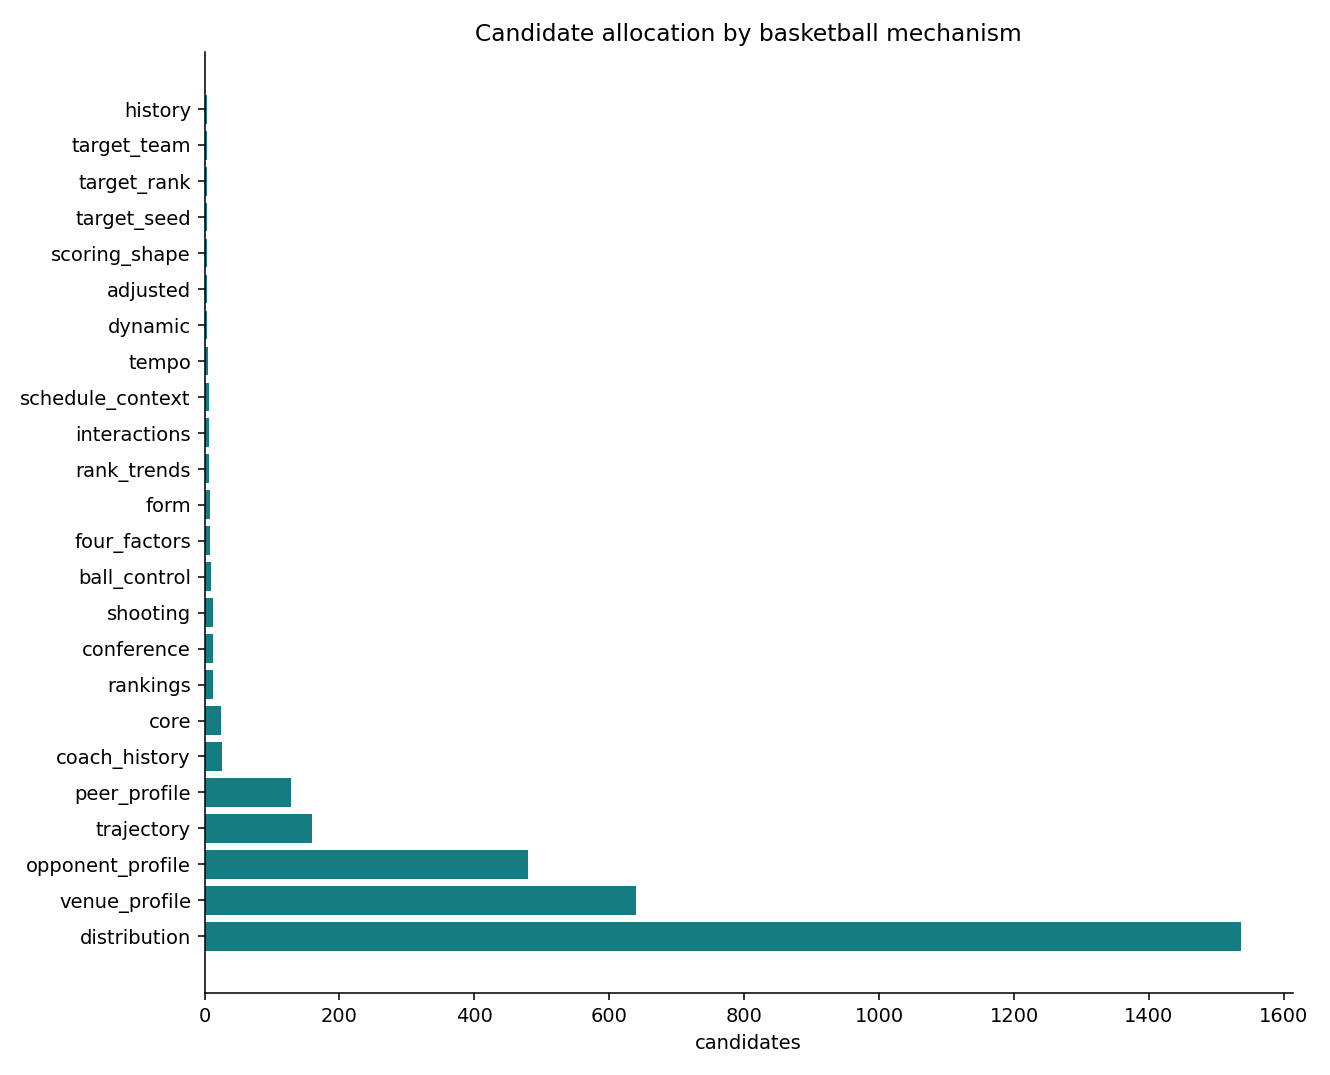

In [3]:
registry = pd.read_csv(RESULTS / "feature_registry.csv")
assert registry.feature.is_unique and len(registry) == 3106
assert not {"y", "ID", "Season", "DayNum"}.intersection(registry.feature)
inventory = registry.groupby("family").agg(candidates=("feature", "size"), provenance=("source", "first")).reset_index()
table(inventory)
bar_view(inventory, "family", "candidates", "Candidate allocation by basketball mechanism")

## Availability is checked season by season

All current-season performance is frozen at day 132. Coach identity must be active at that cutoff; coach performance and tenure use strictly earlier seasons. Missing women’s coach records are not invented. Men’s Massey coverage is measured from legal publication dates for every modeled season, rather than assuming rankings exist only in recent years. Women’s models use the common/no-Massey schema.

In [4]:
coverage = pd.read_csv(RESULTS / "coverage.csv")
table(coverage, {"detailed_coverage": "{:.1%}", "clean_coverage": "{:.1%}"})
display(Markdown("**Verified source availability:** `" + json.dumps(SUMMARY["sources"], sort_keys=True) + "`"))
assert not coverage.query("Gender == 'M' and Season in [2016,2017,2018,2019,2021]").ranking_teams.eq(0).any()
source_coverage = pd.read_csv(RESULTS / "source_coverage.csv")
table(source_coverage.query("Gender == 'M'")[["Season", "regular_teams", "ranking_teams", "ranking_systems", "ranking_fraction", "coach_teams", "conference_teams", "latest_ranking_day"]])
assert source_coverage.latest_ranking_day.dropna().le(132).all()


Gender,Season,teams,detailed_coverage,clean_coverage,ranking_teams,coach_teams,conference_teams
M,2013,347,100.0%,99.8%,347,347.000000,345.000000
M,2014,351,100.0%,99.9%,351,351.000000,350.000000
M,2015,351,100.0%,99.7%,351,351.000000,350.000000
M,2016,351,100.0%,99.8%,351,351.000000,351.000000
M,2017,351,100.0%,99.9%,351,351.000000,351.000000
M,2018,351,100.0%,99.9%,351,351.000000,351.000000
M,2019,353,100.0%,99.9%,353,353.000000,353.000000
M,2021,347,100.0%,99.2%,347,347.000000,347.000000
M,2022,358,100.0%,99.0%,358,358.000000,358.000000
M,2023,363,100.0%,99.1%,363,363.000000,361.000000


**Verified source availability:** `{"massey": true, "mens_coaches": true, "mens_conferences": true, "player_availability": false, "roster_minutes": false, "sample_submission": true, "womens_coaches": false, "womens_conferences": true}`

Season,regular_teams,ranking_teams,ranking_systems,ranking_fraction,coach_teams,conference_teams,latest_ranking_day
1985,282,0,0,0.000000,282,282,NaN
1986,283,0,0,0.000000,283,283,NaN
1987,290,0,0,0.000000,290,290,NaN
1988,290,0,0,0.000000,290,290,NaN
1989,293,0,0,0.000000,293,293,NaN
1990,292,0,0,0.000000,292,292,NaN
1991,295,0,0,0.000000,295,295,NaN
1992,298,0,0,0.000000,298,298,NaN
1993,298,0,0,0.000000,298,298,NaN
1994,301,0,0,0.000000,301,301,NaN


## Historical targets never cross a season boundary

Team, seed and ranking-bin encodings retain each historical season’s seed and ranking. Season Y uses outcomes strictly before Y; the entire current tournament is embargoed. Fixed priors and smoothing are not estimated from future validation seasons. Coach regular-season and tournament histories also exclude current-season outcomes. Automated mutation tests alter future labels and post-cutoff games and require identical earlier features.

In [5]:
encoding = pd.read_csv(RESULTS / "encoding_audit.csv")
observed = encoding.loc[encoding.history_max_season.notna()]
assert (observed.history_max_season < observed.Season).all()
table(encoding.groupby(["Gender", "Season"]).agg(encoding_families=("category", "size"), history_max_season=("history_max_season", "max")).reset_index())

Gender,Season,encoding_families,history_max_season
M,2013,3,NaN
M,2014,3,2013.000000
M,2015,3,2014.000000
M,2016,3,2015.000000
M,2017,3,2016.000000
M,2018,3,2017.000000
M,2019,3,2018.000000
M,2021,3,2019.000000
M,2022,3,2021.000000
M,2023,3,2022.000000


## Screening happens inside each training fold

There is no global feature list selected using validation outcomes. Each training-only screen audits missingness, constants, rare nonzero support, univariate association and absolute correlation. A fixed capacity of 128 limits model dimensionality; duplicate and sign-reversed duplicate signals compete for one slot. Selection, imputation and fitted models are persisted together. Correlation pruning does not prove that rejected inputs are causally irrelevant, and univariate screening can miss pure interaction effects.

In [6]:
screening = pd.read_csv(RESULTS / "screening_summary.csv")
assert (screening.candidate_count == screening.retained_count + screening.rejected_count).all()
assert screening.retained_count.between(1, 128).all()
full = screening.query("block == 'full'")
table(full[["Gender", "Season", "model", "candidate_count", "retained_count", "rejected_count"]])
reasons = [c for c in ["all_missing", "constant", "near_constant", "redundant", "capacity", "no_training_signal", "retained"] if c in full]
table(full.groupby(["Gender", "model"])[reasons].sum().reset_index())

Gender,Season,model,candidate_count,retained_count,rejected_count
M,2016,hist,3106,128,2978
M,2016,logistic,3106,128,2978
M,2017,hist,3106,128,2978
M,2017,logistic,3106,128,2978
M,2018,hist,3106,128,2978
M,2018,logistic,3106,128,2978
M,2019,hist,3106,128,2978
M,2019,logistic,3106,128,2978
M,2021,hist,3106,128,2978
M,2021,logistic,3106,128,2978


Gender,model,near_constant,redundant,capacity,no_training_signal,retained
M,hist,7,1007,13650,226,640
M,logistic,7,1007,13650,226,640
W,hist,3,521,13926,325,640
W,logistic,3,521,13926,325,640


## Selection stability across earlier-season fits

Retention frequency measures whether a signal survives different training histories, not whether it is statistically significant. This table uses the full candidate block only. All underlying per-fit rejection reasons remain in the durable artifact archive.

In [7]:
stability = pd.read_csv(RESULTS / "selection_stability.csv").merge(registry[["feature", "family"]], on="feature", validate="many_to_one")
table(stability.sort_values(["retention_rate", "retained_folds"], ascending=False).groupby(["Gender", "model"], sort=False).head(8))

Gender,model,feature,folds,retained_folds,retention_rate,family
M,hist,diff_adj_defense,5,5,1.000000,adjusted
M,hist,diff_adj_offense,5,5,1.000000,adjusted
M,hist,diff_coach_best_tournament_wins_5,5,5,1.000000,coach_history
M,hist,diff_coach_prior_tournament_appearances_5,5,5,1.000000,coach_history
M,hist,diff_coach_regular_1_margin,5,5,1.000000,coach_history
M,hist,diff_coach_regular_1_win_posterior,5,5,1.000000,coach_history
M,hist,diff_coach_regular_3_margin,5,5,1.000000,coach_history
M,hist,diff_coach_regular_3_win_posterior,5,5,1.000000,coach_history
M,logistic,diff_adj_defense,5,5,1.000000,adjusted
M,logistic,diff_adj_offense,5,5,1.000000,adjusted


## Does a feature family improve Brier score?

The official metric formula is game-weighted Brier, mean squared probability error. Mean-season Brier is the prespecified selection criterion and is reported separately. Whole physical tournament games are scored once; mirrored rows occur only in training. These five development seasons and the later consumed benchmark are retrospective, not an untouched holdout.

Gender,model,block,games,brier,macro_season_brier,log_loss,roc_auc
M,logistic,rankings,334,0.187544,0.187608,0.552164,0.793038
M,logistic,four_factors,334,0.187988,0.188058,0.552180,0.791017
M,logistic,dynamic,334,0.189077,0.189147,0.554157,0.786797
M,hist,without_history,334,0.189634,0.189693,0.561975,0.790188
M,hist,rankings,334,0.189703,0.189798,0.561698,0.786454
M,logistic,target_seed,334,0.190466,0.190539,0.556089,0.785606
M,logistic,ball_control,334,0.190525,0.190589,0.558808,0.787013
M,hist,without_form,334,0.190786,0.190839,0.564782,0.787338
M,logistic,interactions,334,0.190821,0.190902,0.558462,0.783838
M,hist,without_conference,334,0.190903,0.190969,0.564870,0.789899


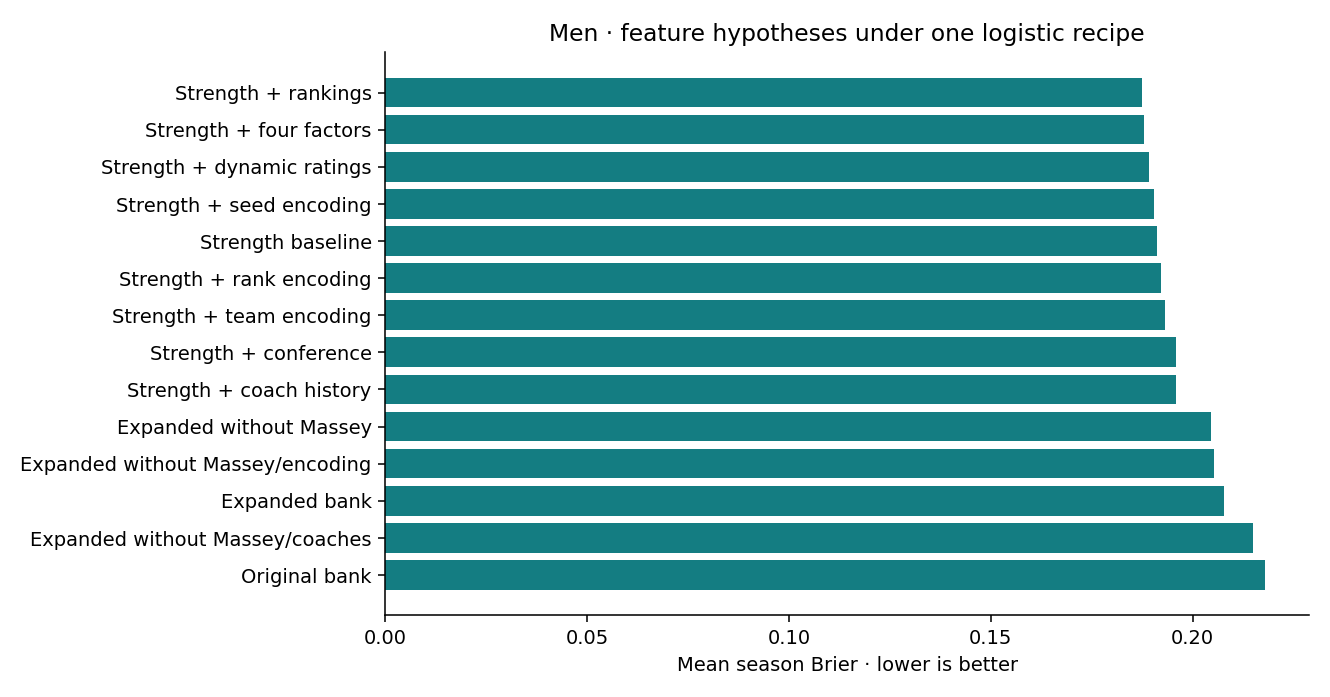

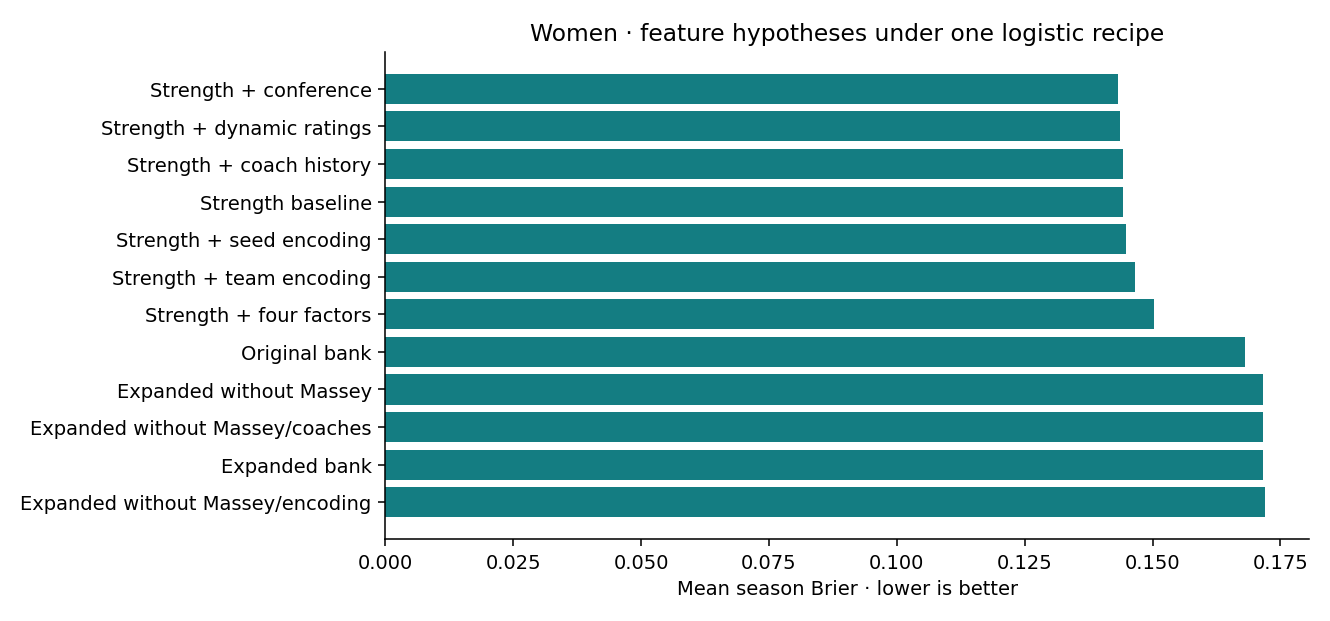

Focused comparison of the requested feature hypotheses. The complete block leaderboard and histogram-boosting results remain in the recorded CSV evidence.

In [8]:
scores = pd.read_csv(RESULTS / "leaderboard.csv")
table(scores.sort_values(["Gender", "macro_season_brier"]).groupby(["Gender", "model"], sort=False).head(6)[["Gender", "model", "block", "games", "brier", "macro_season_brier", "log_loss", "roc_auc"]])
# Fixed, question-driven comparison; the complete leaderboard remains in the report.
comparison_blocks = {
    "strength": "Strength baseline",
    "baseline_124": "Original bank",
    "full": "Expanded bank",
    "expanded_non_massey": "Expanded without Massey",
    "expanded_non_massey_no_coach": "Expanded without Massey/coaches",
    "expanded_non_massey_no_target": "Expanded without Massey/encoding",
    "rankings": "Strength + rankings",
    "coach_history": "Strength + coach history",
    "conference": "Strength + conference",
    "target_team": "Strength + team encoding",
    "target_seed": "Strength + seed encoding",
    "target_rank": "Strength + rank encoding",
    "dynamic": "Strength + dynamic ratings",
    "four_factors": "Strength + four factors",
}
for gender, label in [("M", "Men"), ("W", "Women")]:
    shown = scores.query("Gender == @gender and model == 'logistic'")
    shown = shown.loc[shown.block.isin(comparison_blocks)].copy()
    shown["Feature group"] = shown.block.map(comparison_blocks)
    bar_view(shown[["Feature group", "block", "brier", "macro_season_brier"]],
             "Feature group", "macro_season_brier", label + " · feature hypotheses under one logistic recipe")
display(Markdown("Focused comparison of the requested feature hypotheses. The complete block "
                 "leaderboard and histogram-boosting results remain in the recorded CSV evidence."))


## Paired ablations and uncertainty

Negative Brier differences favor the candidate. Intervals resample complete seasons and pair the same games; with only five development seasons and many comparisons they are exploratory, not corrected significance claims. The explicit `without_massey` comparison removes all 23 ranking-derived inputs together, rather than leaving trend or target-ranking derivatives behind.

In [9]:
intervals = pd.read_csv(RESULTS / "ablation_intervals.csv")
new_families = ["distribution", "venue_profile", "opponent_profile", "trajectory", "peer_profile", "coach_history", "conference"]
selected = intervals.loc[(intervals.candidate.isin(new_families) & intervals.baseline.eq("strength")) | intervals.baseline.eq("without_massey")]
table(selected[["Gender", "model", "candidate", "baseline", "brier_delta", "ci_low", "ci_high", "season_count"]])
assert selected.season_count.eq(5).all()
controlled = intervals.loc[intervals.candidate.isin(["full", "expanded_non_massey"]) & intervals.baseline.str.startswith(("baseline_124", "expanded_non_massey"))]
table(controlled[["Gender", "model", "candidate", "baseline", "brier_delta", "ci_low", "ci_high", "season_count"]])


Gender,model,candidate,baseline,brier_delta,ci_low,ci_high,season_count
M,hist,distribution,strength,0.008713,-0.004564,0.019122,5
M,hist,venue_profile,strength,0.000569,-0.008835,0.012275,5
M,hist,opponent_profile,strength,0.006461,0.001402,0.011430,5
M,hist,trajectory,strength,0.002588,-0.003629,0.007811,5
M,hist,peer_profile,strength,0.003853,-0.008007,0.014801,5
M,hist,coach_history,strength,-0.000424,-0.016345,0.017821,5
M,hist,conference,strength,0.005239,-0.004836,0.013612,5
M,hist,full,without_massey,-0.002479,-0.005519,0.000561,5
M,logistic,distribution,strength,0.032857,0.019986,0.045729,5
M,logistic,venue_profile,strength,0.034884,0.020021,0.051855,5


Gender,model,candidate,baseline,brier_delta,ci_low,ci_high,season_count
M,hist,full,baseline_124,-0.003825,-0.012058,0.004408,5
M,hist,expanded_non_massey,baseline_124,-0.001346,-0.009492,0.007772,5
M,hist,full,expanded_non_massey,-0.002479,-0.005634,0.000761,5
M,hist,expanded_non_massey,expanded_non_massey_no_target,-0.001076,-0.003754,0.001378,5
M,hist,expanded_non_massey,expanded_non_massey_no_coach,-0.006302,-0.014599,0.002199,5
M,hist,expanded_non_massey,expanded_non_massey_no_target_coach,-0.006746,-0.015754,0.003000,5
M,logistic,full,baseline_124,-0.010223,-0.042242,0.024724,5
M,logistic,expanded_non_massey,baseline_124,-0.013474,-0.042571,0.017212,5
M,logistic,full,expanded_non_massey,0.003250,-0.001947,0.008863,5
M,logistic,expanded_non_massey,expanded_non_massey_no_target,-0.000715,-0.003142,0.000807,5


## Are 128 retained features enough?

The 3,106-column bank is a search space. The original 128-input limit was a fixed regularization choice, not an established optimum. This follow-up varies only the retention limit: **32, 64, 128 and 256**, holding the candidate matrix, redundancy threshold, and logistic/histogram recipes fixed. Men are compared with and without Massey; women use the available non-Massey sources.

Every fit screens its own earlier training games. A separate **nested** stream selects the limit by mean-season Brier on strictly earlier OOF seasons; ties favor fewer inputs. We retain all fixed-limit results, including unsuccessful ones. Existing 128-input outer fits are restored from verified checkpoints; cloning their estimator templates discards fitted state before any new training.

This is an exploratory capacity sensitivity study on previously explored development years. It does not make the 2022–2025 benchmark fresh, and it does not automatically replace notebook 03's model selection or notebook 04's frozen recipe.

**Completed capacity study:** `917affd67b01c3e865f8131bb2e4fd3f09fde6f43eeffdfa67fa8081d67c985f`  
**New fits:** 138 · **Verified existing fits reused:** 30

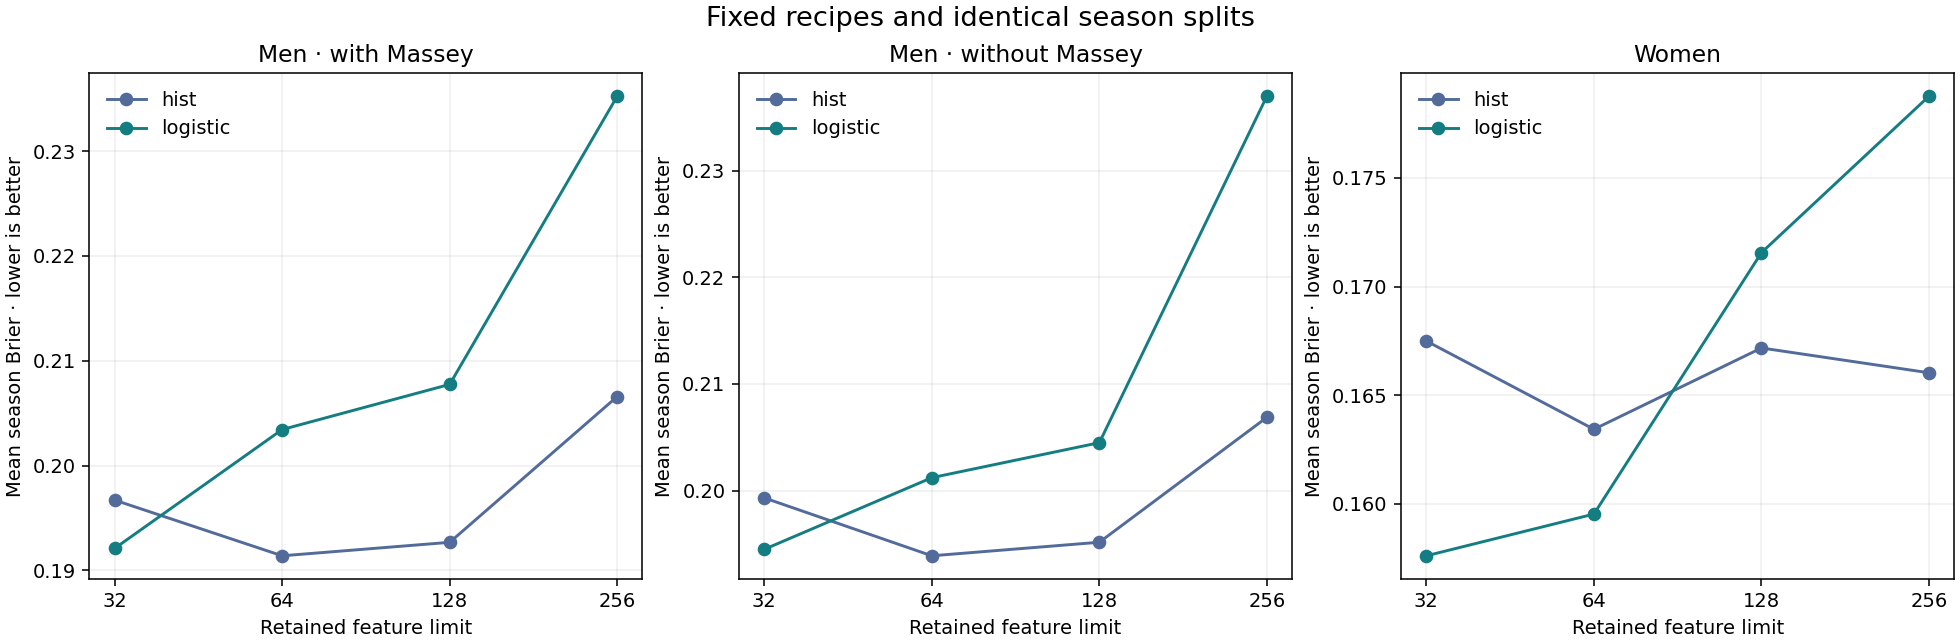

block,route,model,cap_128,cap_256,cap_32,cap_64,nested
,M_common,hist,0.195157,0.206869,0.199318,0.193887,0.194984
,M_common,logistic,0.204492,0.236982,0.194492,0.201210,0.194492
,M_rankings,hist,0.192678,0.206585,0.196706,0.191393,0.196706
,M_rankings,logistic,0.207742,0.235234,0.192095,0.203435,0.192095
,W_common,hist,0.167173,0.166032,0.167492,0.163432,0.167077
,W_common,logistic,0.171561,0.178761,0.157610,0.159531,0.164711


route,model,brier_delta,ci_low,ci_high
M_common,hist,-0.000173,-0.004489,0.004142
M_common,logistic,-0.010000,-0.031819,0.005255
M_rankings,hist,0.004027,-0.005669,0.015233
M_rankings,logistic,-0.015647,-0.044419,0.005356
W_common,hist,-0.000096,-0.007291,0.007115
W_common,logistic,-0.006850,-0.017468,0.003160


In [10]:
from march_mania.publication import capacity
if MODE == "train":
    capacity.run(ROOT)
CAPACITY_DIR, CAPACITY_RECORD = capacity.review(ROOT)
capacity_summary = CAPACITY_RECORD["summary"]
display(Markdown(
    f"**Completed capacity study:** `{capacity_summary['fingerprint']}`  \n"
    f"**New fits:** {capacity_summary['new_fits']} · "
    f"**Verified existing fits reused:** {capacity_summary['inherited_reference_fits']}"
))
capacity_scores = pd.read_csv(CAPACITY_DIR / "leaderboard.csv")
capacity_choices = pd.read_csv(CAPACITY_DIR / "selection.csv")
assert (capacity_choices.history_last_season < capacity_choices.Season).all()
assert (capacity_choices.history_seasons >= 2).all()
labels = {"M_rankings": "Men · with Massey", "M_common": "Men · without Massey", "W_common": "Women"}
capacity_fixed = capacity_scores.query("block != 'nested'").copy()
capacity_fixed["retained_limit"] = capacity_fixed.block.str.removeprefix("cap_").astype(int)
capacity_fixed["population"] = capacity_fixed.route.map(labels)
capacity_fixed = capacity_fixed.sort_values(["population", "model", "retained_limit"])
fig = px.line(capacity_fixed, x="retained_limit", y="macro_season_brier", color="model",
              facet_col="population", markers=True, log_x=True,
              labels={"retained_limit": "Retained feature limit", "macro_season_brier": "Mean season Brier"},
              title="Does retaining more candidates improve Brier score?", height=440)
fig.update_layout(template="plotly_white", margin=dict(l=45, r=25, t=90, b=60))
fig.update_xaxes(tickvals=[32, 64, 128, 256])
fig.update_yaxes(matches=None)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
static, axes = plt.subplots(1, 3, figsize=(14, 4.6), constrained_layout=True)
for ax, (route, label) in zip(axes, labels.items()):
    for model, color in [("hist", "#526b9a"), ("logistic", "#147d82")]:
        panel = capacity_fixed.query("route == @route and model == @model")
        ax.plot(panel.retained_limit, panel.macro_season_brier, marker="o", color=color, label=model)
    ax.set_xscale("log", base=2)
    ax.set_xticks([32, 64, 128, 256], labels=[32, 64, 128, 256])
    ax.set(title=label, xlabel="Retained feature limit", ylabel="Mean season Brier · lower is better")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
static.suptitle("Fixed recipes and identical season splits", fontsize=14)
buffer = io.BytesIO()
static.savefig(buffer, format="png", dpi=140)
plt.close(static)
bundle = {"application/vnd.plotly.v1+json": json.loads(fig.to_json()),
          "image/png": base64.b64encode(buffer.getvalue()).decode(),
          "text/plain": "Feature capacity sensitivity across the same five development seasons"}
display(bundle, raw=True)
table(capacity_scores.pivot(index=["route", "model"], columns="block", values="macro_season_brier").reset_index())
capacity_intervals = pd.read_csv(CAPACITY_DIR / "intervals.csv")
table(capacity_intervals.query("candidate == 'nested'")[["route", "model", "brier_delta", "ci_low", "ci_high"]])


**Measured conclusion.** Forward-selected capacity changes logistic mean-season Brier from 0.207742 to 0.192095 for men with Massey, from 0.204492 to 0.194492 without Massey, and from 0.171561 to 0.164711 for women. All six nested comparisons' season-bootstrap intervals include zero. The smaller broad models still trail the compact leaders in notebook 03.

Retaining 256 inputs generally hurts. This supports stopping blind expansion of the retained feature count. It does not establish 128 as universally optimal, exhaust every possible nonlinear representation, or demonstrate a new forecasting winner. The main model and benchmark recipes retain their original identities; no consumed benchmark was used to select a replacement.

## Durability and interpretation

Snapshots are checkpointed by season and population. Submission features are generated in bounded 512-pair chunks; completed chunks are checksum-verified on resume. Every estimator, selection decision and prediction task has source/data/runtime fingerprints, UTC progress events and heartbeats. A changed feature definition cannot silently reuse old scores. Notebook 03 retrains against this exact feature fingerprint; notebook 05 compares matched old/new predictions. The largest candidate block is not automatically the winning model.